### Table of Contents
1. [Introduction](#Introduction)
2. [Data - Loading and Preprocessing](#Data)
   1. [Loading](##Loading)
   2. [Preprocessing](##Preprocessing)

# Introduction
Here you will find a deep dive into the pre-processed data from MIMIC-III. This is an attempt to **evaluate the motivation** behind specific models and suggest an improved method.

# Data

In [21]:
from collections import defaultdict
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

In [22]:
from src.load.MIMIC3Loader import MIMIC3Loader, MIMIC3LoaderConfig
from src.preprocess.MIMIC3Preprocessor import MIMIC3Preprocessor

### Loading

In [23]:
cfg = MIMIC3LoaderConfig()
loader = MIMIC3Loader(cfg=cfg)
response = loader.load()

### Preprocessing

In [24]:
preprocessor = MIMIC3Preprocessor()
data = preprocessor.process(response)

In [38]:
train_df = data.tables["train"]
train_df = train_df.copy()
train_df['ADMITTIME'] = pd.to_datetime(train_df['ADMITTIME'])

val_df = data.tables["val"]
val_df = val_df.copy()
val_df['ADMITTIME'] = pd.to_datetime(val_df['ADMITTIME'])

test_df = data.tables["test"]
test_df = test_df.copy()
test_df['ADMITTIME'] = pd.to_datetime(test_df['ADMITTIME'])

full_df = pd.concat([train_df, val_df, test_df], axis=0)
full_df = full_df.sort_values(["SUBJECT_ID", "ADMITTIME"])

full_df.reset_index(drop=True, inplace=True)

In [92]:
def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)

def compute_jaccard_similarity(df, subject_col, meds_col, time_gap=1, show_graph=False, print_out=False):
    """
    Computes and plots Jaccard similarity between consecutive medication sequences in a DataFrame.

    Args:
    - df (pd.DataFrame): DataFrame containing medication sequences with 'subject_col' and 'meds_col'.
    - subject_col (str): The column name for the subject identifier.
    - meds_col (str): The column name for the medication codes.
    - time_gap (int): The time gap for comparing sequences (default is 1 for t vs t-1).
    
    Returns:
    - mean_jaccard (float): The mean Jaccard similarity score.
    """
    # List to store Jaccard scores
    jaccard_scores = []

    # Group by SUBJECT_ID and calculate Jaccard similarity for each subject
    for subject_id, g in df.groupby(subject_col, sort=False):
        meds_seq = g[meds_col].values  # This will return a numpy array of lists
        for t in range(time_gap, len(meds_seq)):
            jaccard_scores.append(jaccard(meds_seq[t], meds_seq[t-time_gap]))

    # Calculate the mean Jaccard score
    mean_jaccard = sum(jaccard_scores) / len(jaccard_scores)
    if print_out:
        print("Mean Jaccard (t vs t-{}) of meds:".format(time_gap), mean_jaccard)

    # Plot the Jaccard similarity distribution
    if show_graph:
        plt.figure(figsize=(12, 6))
        plt.hist(jaccard_scores, bins=30, color='skyblue', edgecolor='black')
        plt.title(f'Jaccard Similarity Distribution (t vs t-{time_gap})')
        plt.xlabel('Jaccard Similarity')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.show()

    return mean_jaccard

def plot_mean_jaccard_for_multiple_gaps(df, subject_col, meds_col, time_gaps=[1], print_out=False):
    """
    Computes and plots the mean Jaccard similarity for multiple time gaps (t vs t-n).

    Args:
    - df (pd.DataFrame): DataFrame containing medication sequences with 'subject_col' and 'meds_col'.
    - subject_col (str): The column name for the subject identifier.
    - meds_col (str): The column name for the medication codes.
    - time_gaps (list): List of time gaps (n) to compare (e.g., [1, 2, 3]).
    """
    mean_jaccards = []  # List to store the mean Jaccard for each gap

    # Iterate over each time gap
    for gap in time_gaps:
        if print_out:
            print(f"Computing Jaccard similarity for time gap t vs t-{gap}...")
        
        # Compute mean Jaccard for the current time gap using the original function
        mean_jaccard = compute_jaccard_similarity(df, subject_col, meds_col, time_gap=gap, print_out=print_out)
        
        # Store the mean Jaccard for this time gap
        mean_jaccards.append(mean_jaccard)

    # Plotting the mean Jaccard similarities for each time gap
    plt.figure(figsize=(12, 6))
    plt.plot(time_gaps, mean_jaccards, marker='o', linestyle='-', color='b')
    plt.title('Mean Jaccard Similarity for Different Time Gaps')
    plt.xlabel('Time Gap (t vs t-n)')
    plt.ylabel('Mean Jaccard Similarity')
    plt.xticks(time_gaps)
    plt.grid(True)
    plt.show()
    
def plot_jaccard_vs_time_diff(df, subject_col, meds_col, time_col):
    """
    Plots Jaccard similarity against time difference between consecutive medication sequences.

    Args:
    - df (pd.DataFrame): DataFrame containing the medication sequences and time data.
    - subject_col (str): The column name for the subject identifier.
    - meds_col (str): The column name for the medication codes.
    - time_col (str): The column name for the admission time (datetime).
    """
    X, y = [], []
    
    for subject_id, g in df.groupby(subject_col, sort=False):
        meds_seq = g[meds_col].values
        time_seq = g[time_col].values
        
        for t in range(1, len(meds_seq)):
            # Calculate the time difference between t and t-1 (in seconds)
            time_diff = (time_seq[t] - time_seq[t-1]).astype('timedelta64[s]').view('int64')
            X.append(time_diff)
            
            # Calculate Jaccard similarity between t and t-1
            y.append(jaccard(meds_seq[t], meds_seq[t-1]))
            
    X = np.array(X)
    y = np.array(y)

    # Compute Pearson correlation
    correlation = np.corrcoef(X, y)[0, 1]
    print(f"Pearson Correlation between Time Difference and Jaccard Similarity: {correlation}")
    
    z = np.polyfit(X, y, 1)
    p = np.poly1d(z)

    
    # Create the scatter plot
    plt.figure(figsize=(16, 6))
    plt.scatter(y, X, color='blue', alpha=0.5)
    plt.plot(p(X), X, color='red', linestyle='--')
    plt.title('Jaccard Similarity vs Time Difference')
    plt.ylabel('Time Difference (seconds)')
    plt.xlabel('Jaccard Similarity')
    plt.grid(True)
    plt.show()

Mean Jaccard (t vs t-1) of meds: 0.25834903645856455


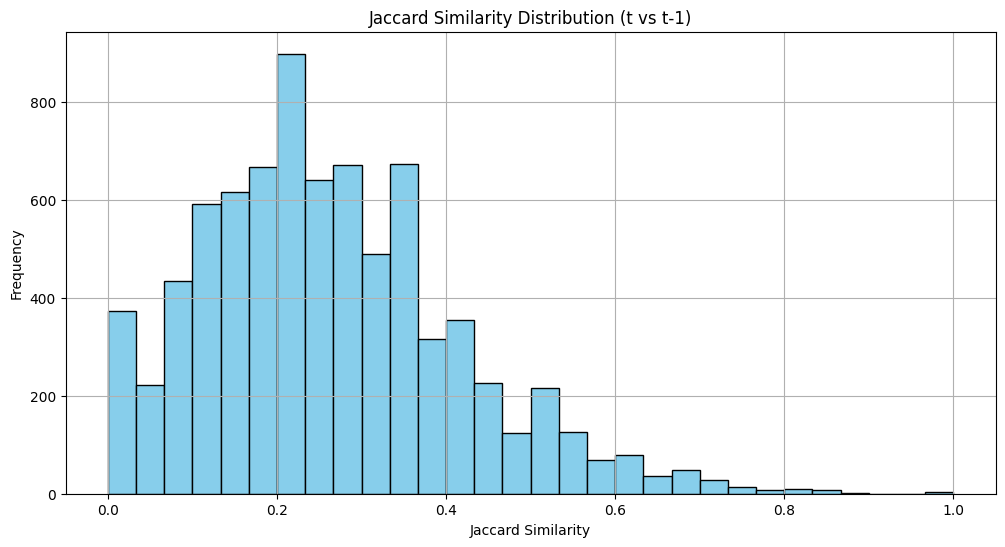

In [81]:
mean_val = compute_jaccard_similarity(full_df, subject_col="SUBJECT_ID", meds_col="MED_CODES", time_gap=1, show_graph=True, print_out=True)

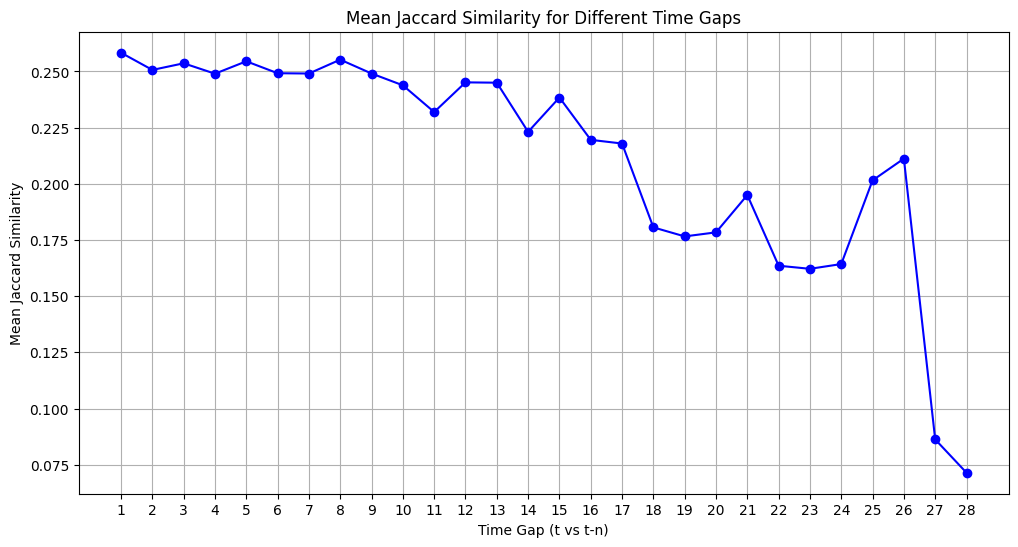

In [82]:
plot_mean_jaccard_for_multiple_gaps(full_df, subject_col="SUBJECT_ID", meds_col="MED_CODES", time_gaps=np.arange(1, 29))

Pearson Correlation between Time Difference and Jaccard Similarity: -0.12140370071781603


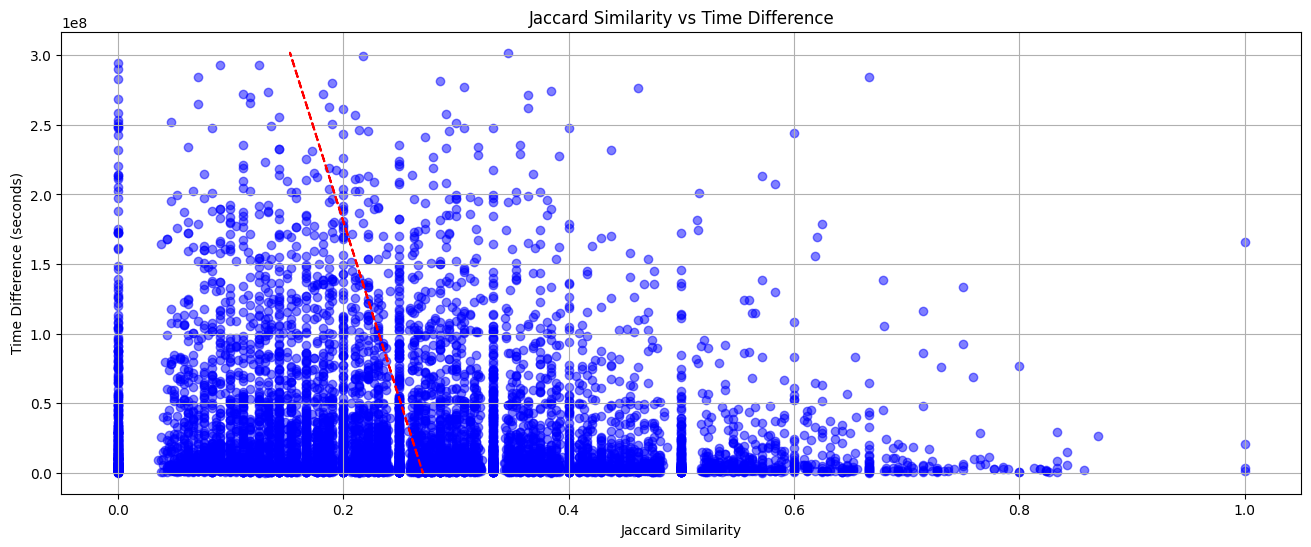

In [93]:
plot_jaccard_vs_time_diff(full_df, subject_col="SUBJECT_ID", meds_col="MED_CODES", time_col="ADMITTIME")